In [1]:
%rm -rf AutoVision-Perception
!git clone https://github.com/Mohamed-Elkady-05/AutoVision-Perception.git
%cd AutoVision-Perception

Cloning into 'AutoVision-Perception'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (187/187), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 187 (delta 70), reused 130 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (187/187), 5.19 MiB | 20.99 MiB/s, done.
Resolving deltas: 100% (70/70), done.
/content/AutoVision-Perception


# Helper Functions

In [1]:
import sys
import os

# Define the explicit path to the project directory
project_directory = "/content/AutoVision-Perception"

# Add the project directory to sys.path if not already present
if project_directory not in sys.path:
    sys.path.append(project_directory)
    print(f"Project directory '{project_directory}' added to sys.path.")
else:
    print(f"Project directory '{project_directory}' is already in sys.path.")

# Print sys.path for verification
print("sys.path contents:")
for path in sys.path:
    print(f"- {path}")

Project directory '/content/AutoVision-Perception' added to sys.path.
sys.path contents:
- /content
- /env/python
- /usr/lib/python312.zip
- /usr/lib/python3.12
- /usr/lib/python3.12/lib-dynload
- 
- /usr/local/lib/python3.12/dist-packages
- /usr/lib/python3/dist-packages
- /usr/local/lib/python3.12/dist-packages/IPython/extensions
- /root/.ipython
- /content/AutoVision-Perception


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

from base_sequential_models import GRUModel
from  GRU_experiment import train_model, evaluate_model

RESULTS_DIR = "./results"
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# GTSRB class names (index = class id)
CLASS_NAMES = [
    "Speed 20",    "Speed 30",    "Speed 50",    "Speed 60",    "Speed 70",
    "Speed 80",    "End 80",      "Speed 100",   "Speed 120",   "No passing",
    "No passing+", "Priority",    "Priority rd", "Yield",       "Stop",
    "No vehicles", "No trucks",   "No entry",    "Caution",     "Left curve",
    "Right curve", "Double curve","Bumpy road",  "Slippery rd", "Narrow rd",
    "Work ahead",  "Traffic sig", "Pedestrians", "Child cross", "Bike cross",
    "Ice/snow",    "Wild animal", "End restrict","Turn right",  "Turn left",
    "Ahead only",  "Ahead/right", "Ahead/left",  "Roundabout",  "End no pass",
    "End no pass+","Speed 100 end", "Speed 120 end"
]

# ==============================================================================
# PLOT 1: TRAINING CURVES
# ==============================================================================

def plot_training_curves(trainer, model_name, save=True):
    """
    Plot loss and accuracy over epochs for train and validation sets.

    Args:
        trainer : UnifiedTrainer returned by train_model()
        save    : save the plot to results/ if True

    Example:
        plot_training_curves(trainer)
    """
    history = trainer.history
    epochs  = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"{model_name} Training Curves", fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="steelblue", linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(x=trainer.best_epoch, color="red", linestyle=":", alpha=0.6, label=f"Best epoch ({trainer.best_epoch})")
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train", color="coral")
    axes[1].plot(epochs, history["val_acc"],   label="Val",   color="coral", linestyle="--")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=trainer.best_epoch, color="red", linestyle=":", alpha=0.6, label=f"Best epoch ({trainer.best_epoch})")
    axes[1].legend()

    plt.tight_layout()

    if save:
        path = f"{RESULTS_DIR}/training_curves.png"
        plt.savefig(path, dpi=120)
        print(f"Saved: {path}")

    plt.show()


# ==============================================================================
# PLOT 2: CONFUSION MATRIX
# ==============================================================================

def plot_confusion_matrix(metrics, model_name, save=True):
    """
    Plot confusion matrix heatmap showing which classes get confused.

    Args:
        metrics : dict returned by evaluate_model()
        save    : save the plot to results/ if True

    Example:
        plot_confusion_matrix(metrics)
    """
    cm = np.array(metrics["confusion_matrix"])

    # Normalize rows so each cell = % of actual class
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)  # handle classes with 0 samples

    fig, ax = plt.subplots(figsize=(18, 16))

    sns.heatmap(
        cm_normalized,
        annot=False,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.3,
        ax=ax,
        vmin=0, vmax=1,
    )

    ax.set_xlabel("Predicted Class", fontsize=12)
    ax.set_ylabel("Actual Class",    fontsize=12)
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)

    plt.tight_layout()

    if save:
        path = f"{RESULTS_DIR}/confusion_matrix.png"
        plt.savefig(path, dpi=120)
        print(f"Saved: {path}")

    plt.show()


# ==============================================================================
# PLOT 3: PER-CLASS ACCURACY
# ==============================================================================

def plot_per_class_accuracy(metrics, model_name, save=False):
    """
    Bar chart showing accuracy for each of the 43 GTSRB classes individually.
    Helps spot which sign types the model struggles with.

    Args:
        metrics : dict returned by evaluate_model()
        save    : save the plot to results/ if True

    Example:
        plot_per_class_accuracy(metrics)
    """
    cm        = np.array(metrics["confusion_matrix"])
    per_class = cm.diagonal() / cm.sum(axis=1).clip(min=1)  # accuracy per class

    # Sort by accuracy so worst classes are easy to spot
    sorted_idx = np.argsort(per_class)
    sorted_acc = per_class[sorted_idx]
    sorted_names = [CLASS_NAMES[i] for i in sorted_idx]

    colors = ["#d73027" if a < 0.5 else "#fc8d59" if a < 0.75 else "#91cf60" if a < 0.9 else "#1a9850"
              for a in sorted_acc]

    fig, ax = plt.subplots(figsize=(10, 14))

    bars = ax.barh(sorted_names, sorted_acc, color=colors)
    ax.set_xlabel("Accuracy")
    ax.set_title(f"{model_name} Per-Class Accuracy", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.1)
    ax.axvline(x=metrics["accuracy"], color="black", linestyle="--", alpha=0.5, label=f"Overall: {metrics['accuracy']:.3f}")
    ax.legend()
    ax.grid(True, axis="x", alpha=0.3)

    for bar, val in zip(bars, sorted_acc):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=8)

    plt.tight_layout()

    if save:
        path = f"{RESULTS_DIR}/per_class_accuracy.png"
        plt.savefig(path, dpi=120)
        print(f"Saved: {path}")

    plt.show()

# Loading and Processing the data

In [3]:
import kagglehub
import os

print("Downloading GTSRB Dataset...")
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

data_path = os.path.join(path, 'Train')
if not os.path.exists(data_path):
    data_path = os.path.join(path, 'train')

print(f"Dataset downloaded and the train folder located at: {data_path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded and the train folder located at: /kaggle/input/gtsrb-german-traffic-sign/Train


In [4]:
import torch
import numpy as np

# Force PyTorch to use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
from pathlib import Path
from feature_extractor_vgg16 import VGG16FeatureExtractor
from google.colab import drive

drive.mount('/content/drive')

# Set cache dir to Google Drive instead of local
CACHE_DIR = "/content/drive/MyDrive/gtsrb_cache"

# Collect all images
train_images = [str(p) for p in Path(data_path).rglob("*.png")]
print(f"Found {len(train_images)} images")
print(train_images[0])  # check one path looks right

# Extract VGG16 features and cache them
extractor = VGG16FeatureExtractor()

if not Path(CACHE_DIR).exists() or not any(Path(CACHE_DIR).iterdir()):
    extractor.extract_and_cache(
        image_paths=train_images,
        cache_key="gtsrb_train",
        cache_dir=CACHE_DIR
    )
else:
    print("Cache already exists, skipping extraction.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 39209 images
/kaggle/input/gtsrb-german-traffic-sign/Train/7/00007_00041_00020.png
[FeatureExtractor] Loading VGG16 from torchvision...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[FeatureExtractor] Initialized on device: cuda
[FeatureExtractor] Feature dimension: 512
Cache already exists, skipping extraction.


In [6]:
import pickle
import numpy as np
from pathlib import Path

save_dir = Path("/content/drive/MyDrive/gtsrb_cache/npy")

# Check if the .npy files already exist (e.g., check for class_0_features.npy)
expected_first_npy = save_dir / "class_0_features.npy"

if save_dir.exists() and expected_first_npy.exists():
    print("Pre-processed .npy features already exist. Skipping loading .pkl and saving .npy files.")
else:
    print("Pre-processed .npy features not found or incomplete. Processing from .pkl...")
    save_dir.mkdir(parents=True, exist_ok=True)

    # Load the pkl
    with open("/content/drive/MyDrive/gtsrb_cache/gtsrb_train_features.pkl", "rb") as f:
        features = pickle.load(f)

    # We also need the labels — get them from the image paths
    image_paths = sorted([str(p) for p in Path(data_path).rglob("*.png")])

    # Extract label from folder name (GTSRB structure: Train/0/image.png → label 0)
    labels = [int(Path(p).parent.name) for p in image_paths]

    for class_id in range(43):
        class_mask = np.array(labels) == class_id
        class_features = features[class_mask]
        np.save(save_dir / f"class_{class_id}_features.npy", class_features)
        print(f"Class {class_id}: {class_features.shape[0]} samples")

print("Done with .npy feature preparation.")

Pre-processed .npy features already exist. Skipping loading .pkl and saving .npy files.
Done with .npy feature preparation.


# RNN Model

## Training

In [8]:
from ModelsP import load_data, build_model, train_model, evaluate_model

train_loader, val_loader, test_loader = load_data()
model   = build_model(model_type='rnn')
trainer = train_model(model, train_loader, val_loader)
metrics = evaluate_model(trainer, test_loader)


[SequenceDataset] Loaded 27175 sequences for split='train'
[SequenceDataset] Loaded 5823 sequences for split='val'
[SequenceDataset] Loaded 5824 sequences for split='test'
Train batches : 849
Val   batches : 182
Test  batches : 182
Model      : RNN
Parameters : 930,859
Device     : cuda
[Trainer] Initialized for model: RNN
[Trainer] Total parameters: 930,859
[Trainer] Device: cuda

[Trainer] Starting training for 30 epochs...
  Epoch 1 [100/849] Loss: 1.8717
  Epoch 1 [200/849] Loss: 1.2290
  Epoch 1 [300/849] Loss: 1.3343
  Epoch 1 [400/849] Loss: 1.1831
  Epoch 1 [500/849] Loss: 1.0602
  Epoch 1 [600/849] Loss: 0.7913
  Epoch 1 [700/849] Loss: 0.8172
  Epoch 1 [800/849] Loss: 0.7518
Epoch 1/30 | Train Loss: 1.3360, Acc: 0.5473 | Val Loss: 0.7909, Acc: 0.6758
  → Checkpoint saved: checkpoints/RNN_best.pt
  Epoch 2 [100/849] Loss: 1.0424
  Epoch 2 [200/849] Loss: 1.1254
  Epoch 2 [300/849] Loss: 0.7452
  Epoch 2 [400/849] Loss: 0.9079
  Epoch 2 [500/849] Loss: 0.6185
  Epoch 2 [600/849

## Plots

Saved: ./results/training_curves.png


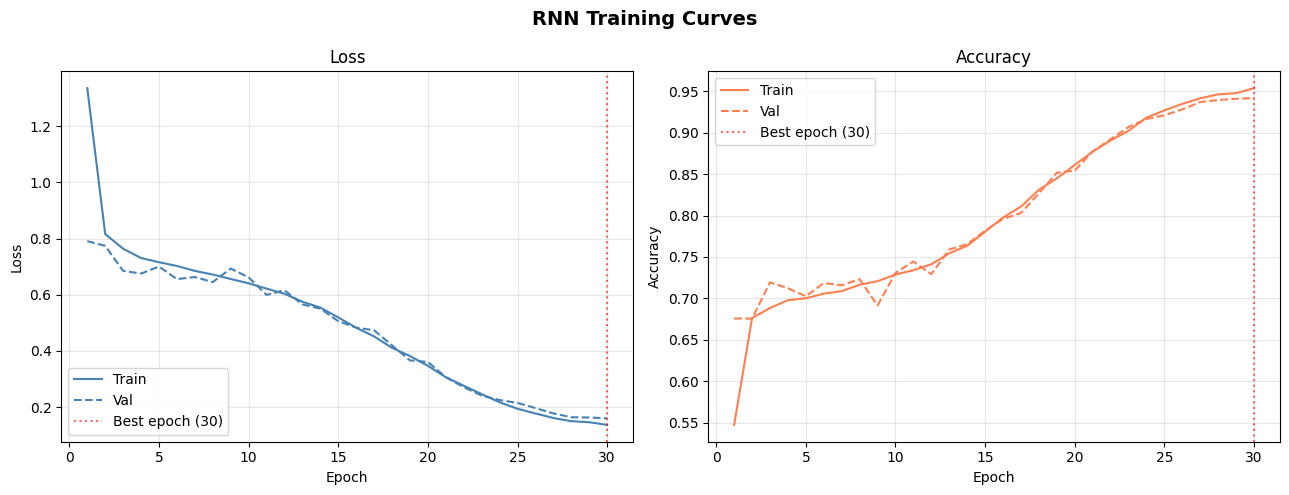

In [16]:
plot_training_curves(trainer,"RNN")

Saved: ./results/confusion_matrix.png


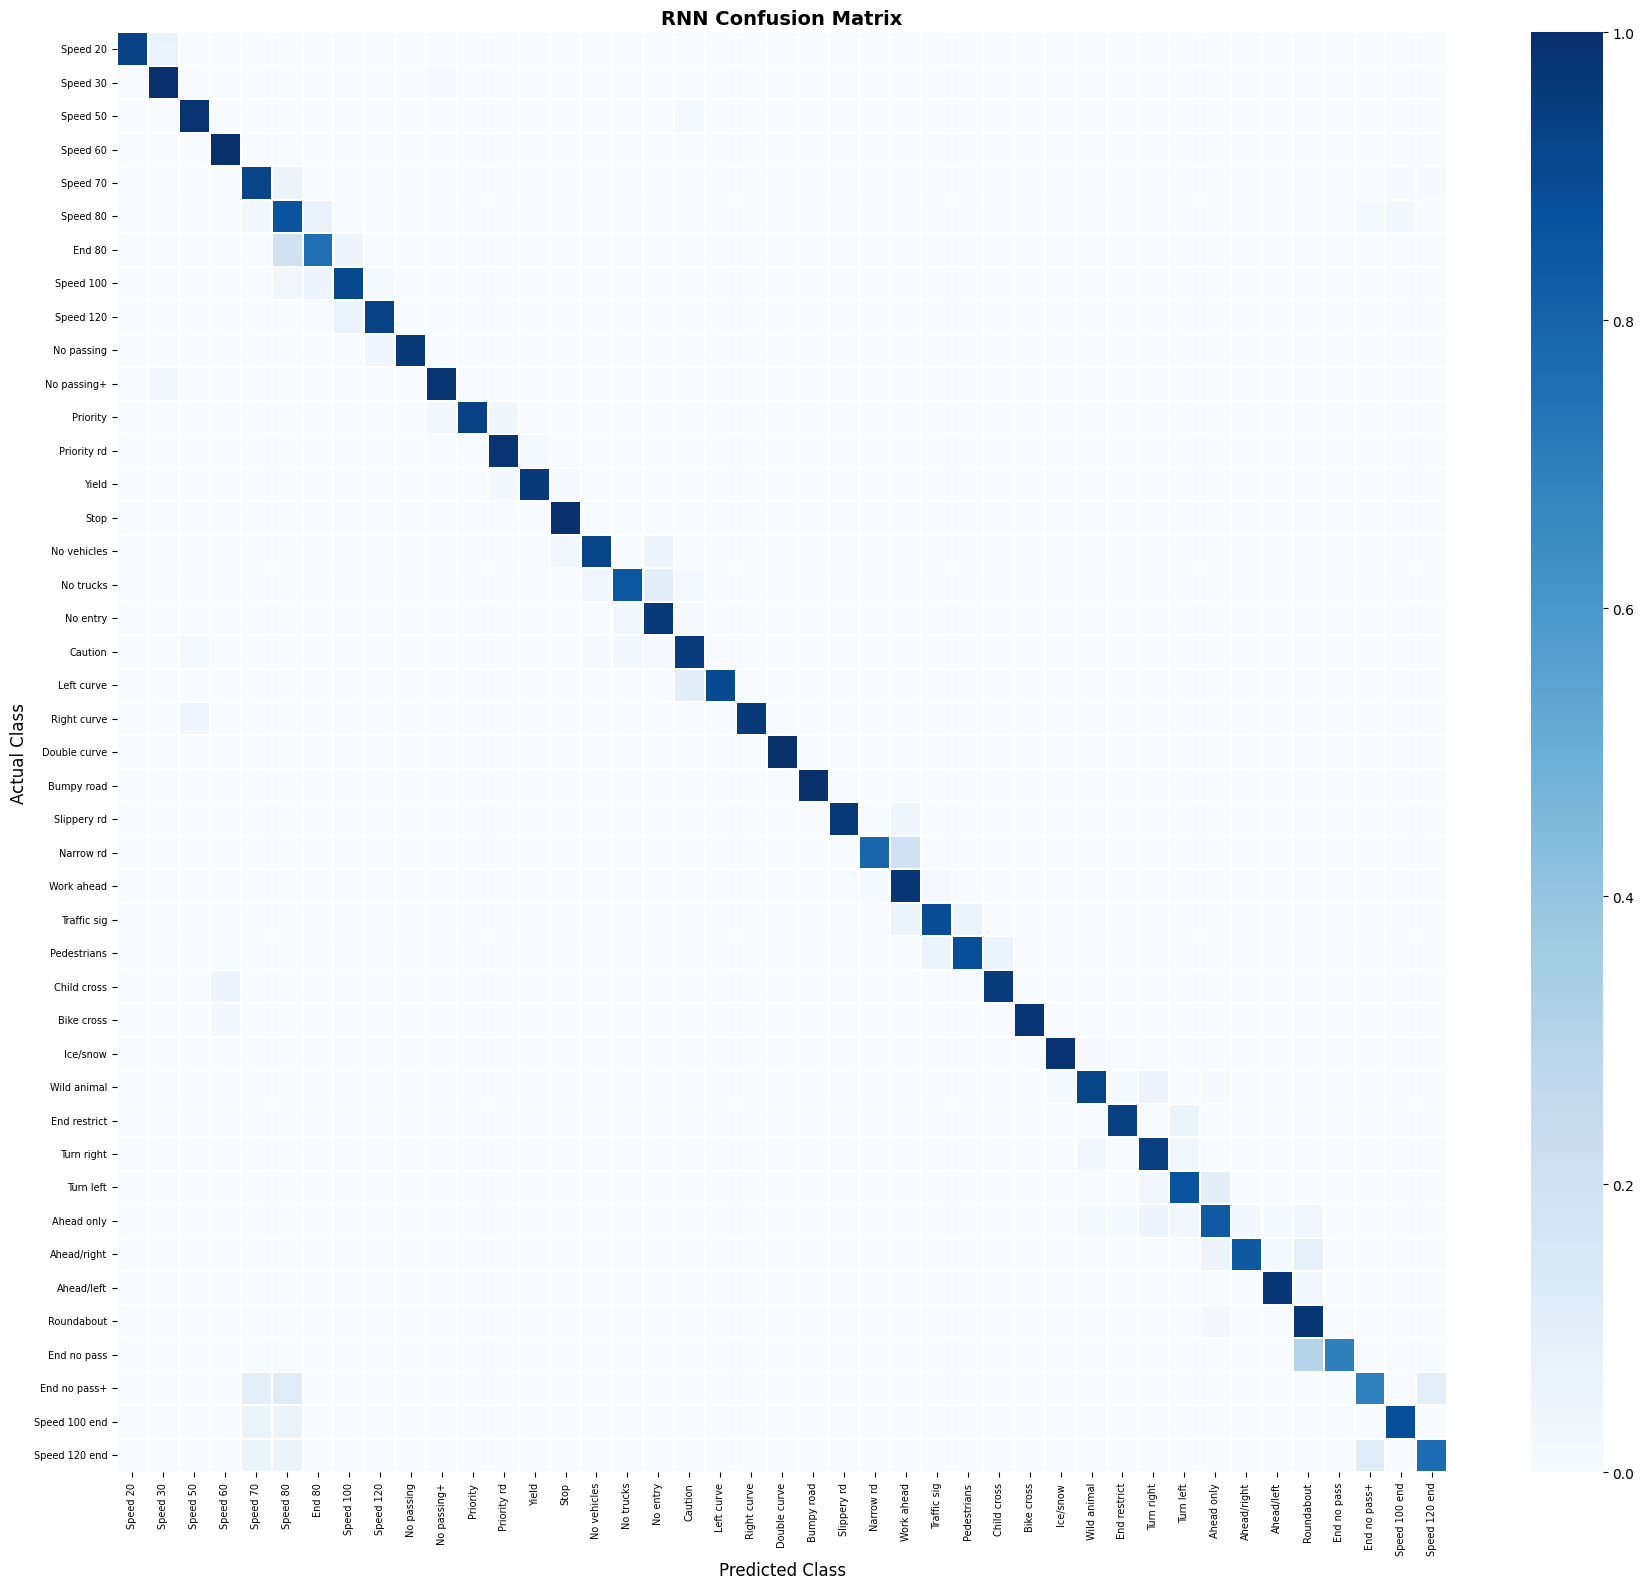

In [17]:
plot_confusion_matrix(metrics,"RNN")

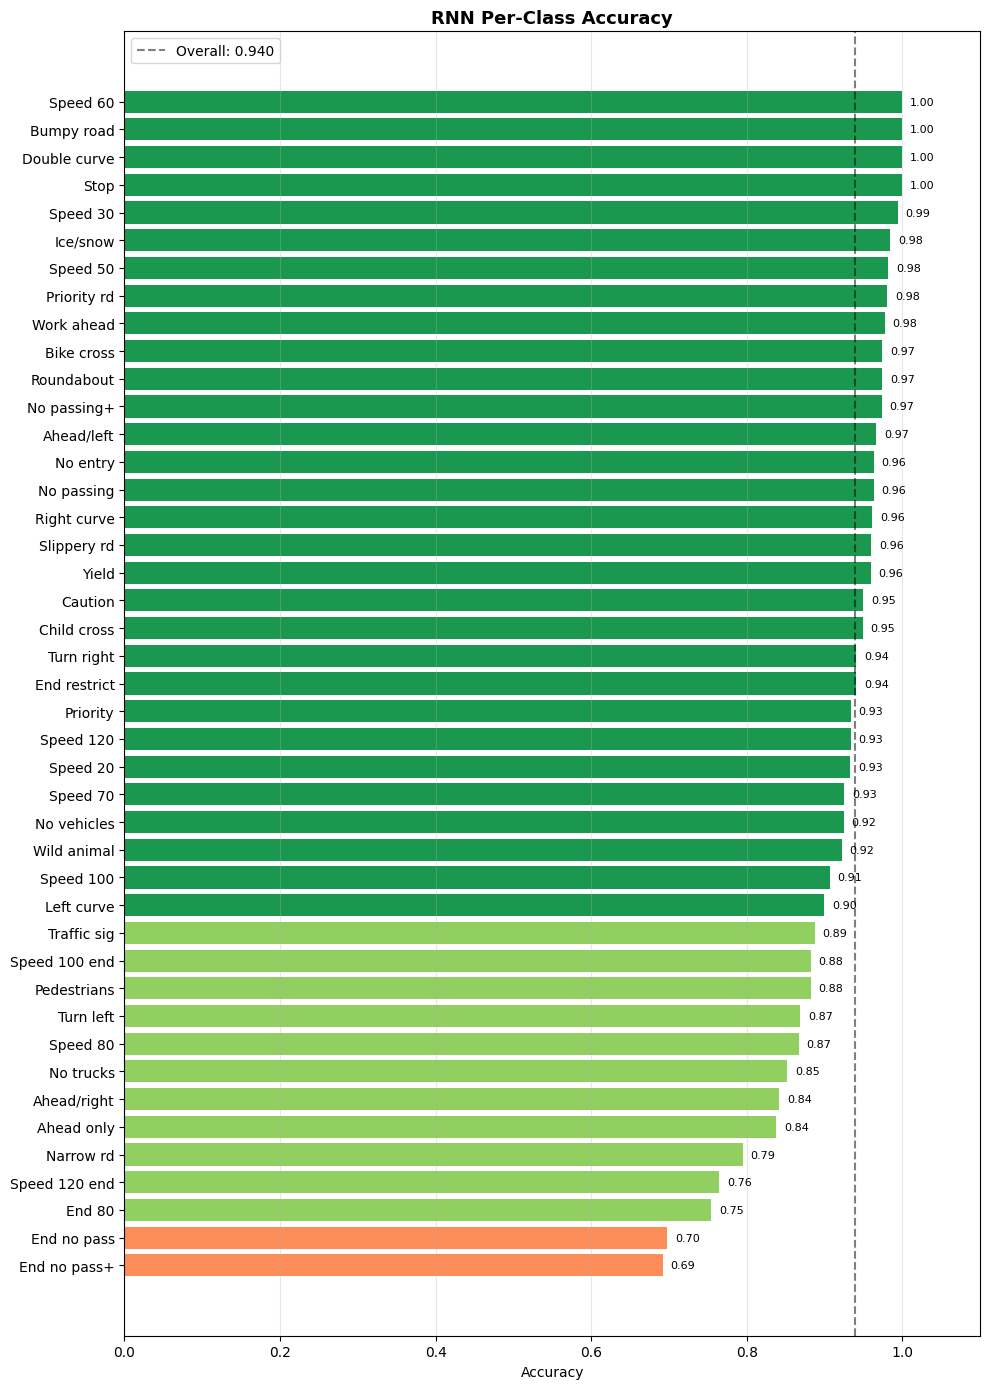

In [18]:
plot_per_class_accuracy(metrics,"RNN")

# GRU Model

## Training the model

In [19]:
from ModelsP import load_data, build_model, train_model, evaluate_model

train_loader, val_loader, test_loader = load_data()
model   = build_model()
trainer = train_model(model, train_loader, val_loader)
metrics = evaluate_model(trainer, test_loader)

[SequenceDataset] Loaded 27175 sequences for split='train'
[SequenceDataset] Loaded 5823 sequences for split='val'
[SequenceDataset] Loaded 5824 sequences for split='test'
Train batches : 849
Val   batches : 182
Test  batches : 182
Model      : GRU
Parameters : 2,507,819
Device     : cuda
[Trainer] Initialized for model: GRU
[Trainer] Total parameters: 2,507,819
[Trainer] Device: cuda

[Trainer] Starting training for 30 epochs...
  Epoch 1 [100/849] Loss: 2.0358
  Epoch 1 [200/849] Loss: 1.2276
  Epoch 1 [300/849] Loss: 1.1354
  Epoch 1 [400/849] Loss: 1.2026
  Epoch 1 [500/849] Loss: 1.2181
  Epoch 1 [600/849] Loss: 0.8671
  Epoch 1 [700/849] Loss: 0.9481
  Epoch 1 [800/849] Loss: 0.7042
Epoch 1/30 | Train Loss: 1.2389, Acc: 0.5738 | Val Loss: 0.7498, Acc: 0.7125
  → Checkpoint saved: checkpoints/GRU_best.pt
  Epoch 2 [100/849] Loss: 0.7192
  Epoch 2 [200/849] Loss: 0.7685
  Epoch 2 [300/849] Loss: 0.8111
  Epoch 2 [400/849] Loss: 0.9450
  Epoch 2 [500/849] Loss: 0.8215
  Epoch 2 [600

## Plots

Saved: ./results/training_curves.png


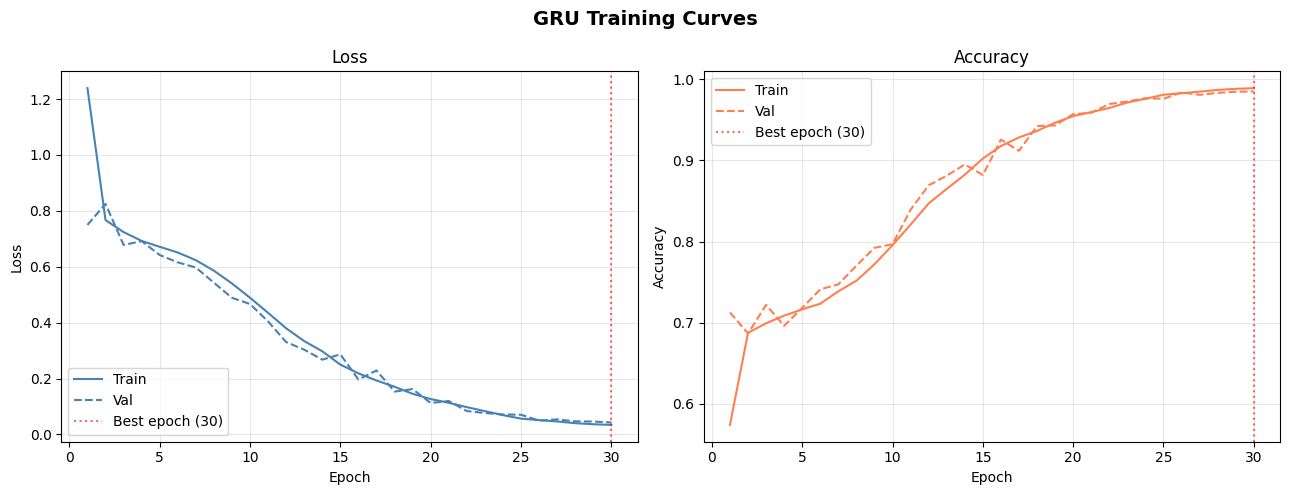

In [20]:
plot_training_curves(trainer,"GRU")

Saved: ./results/confusion_matrix.png


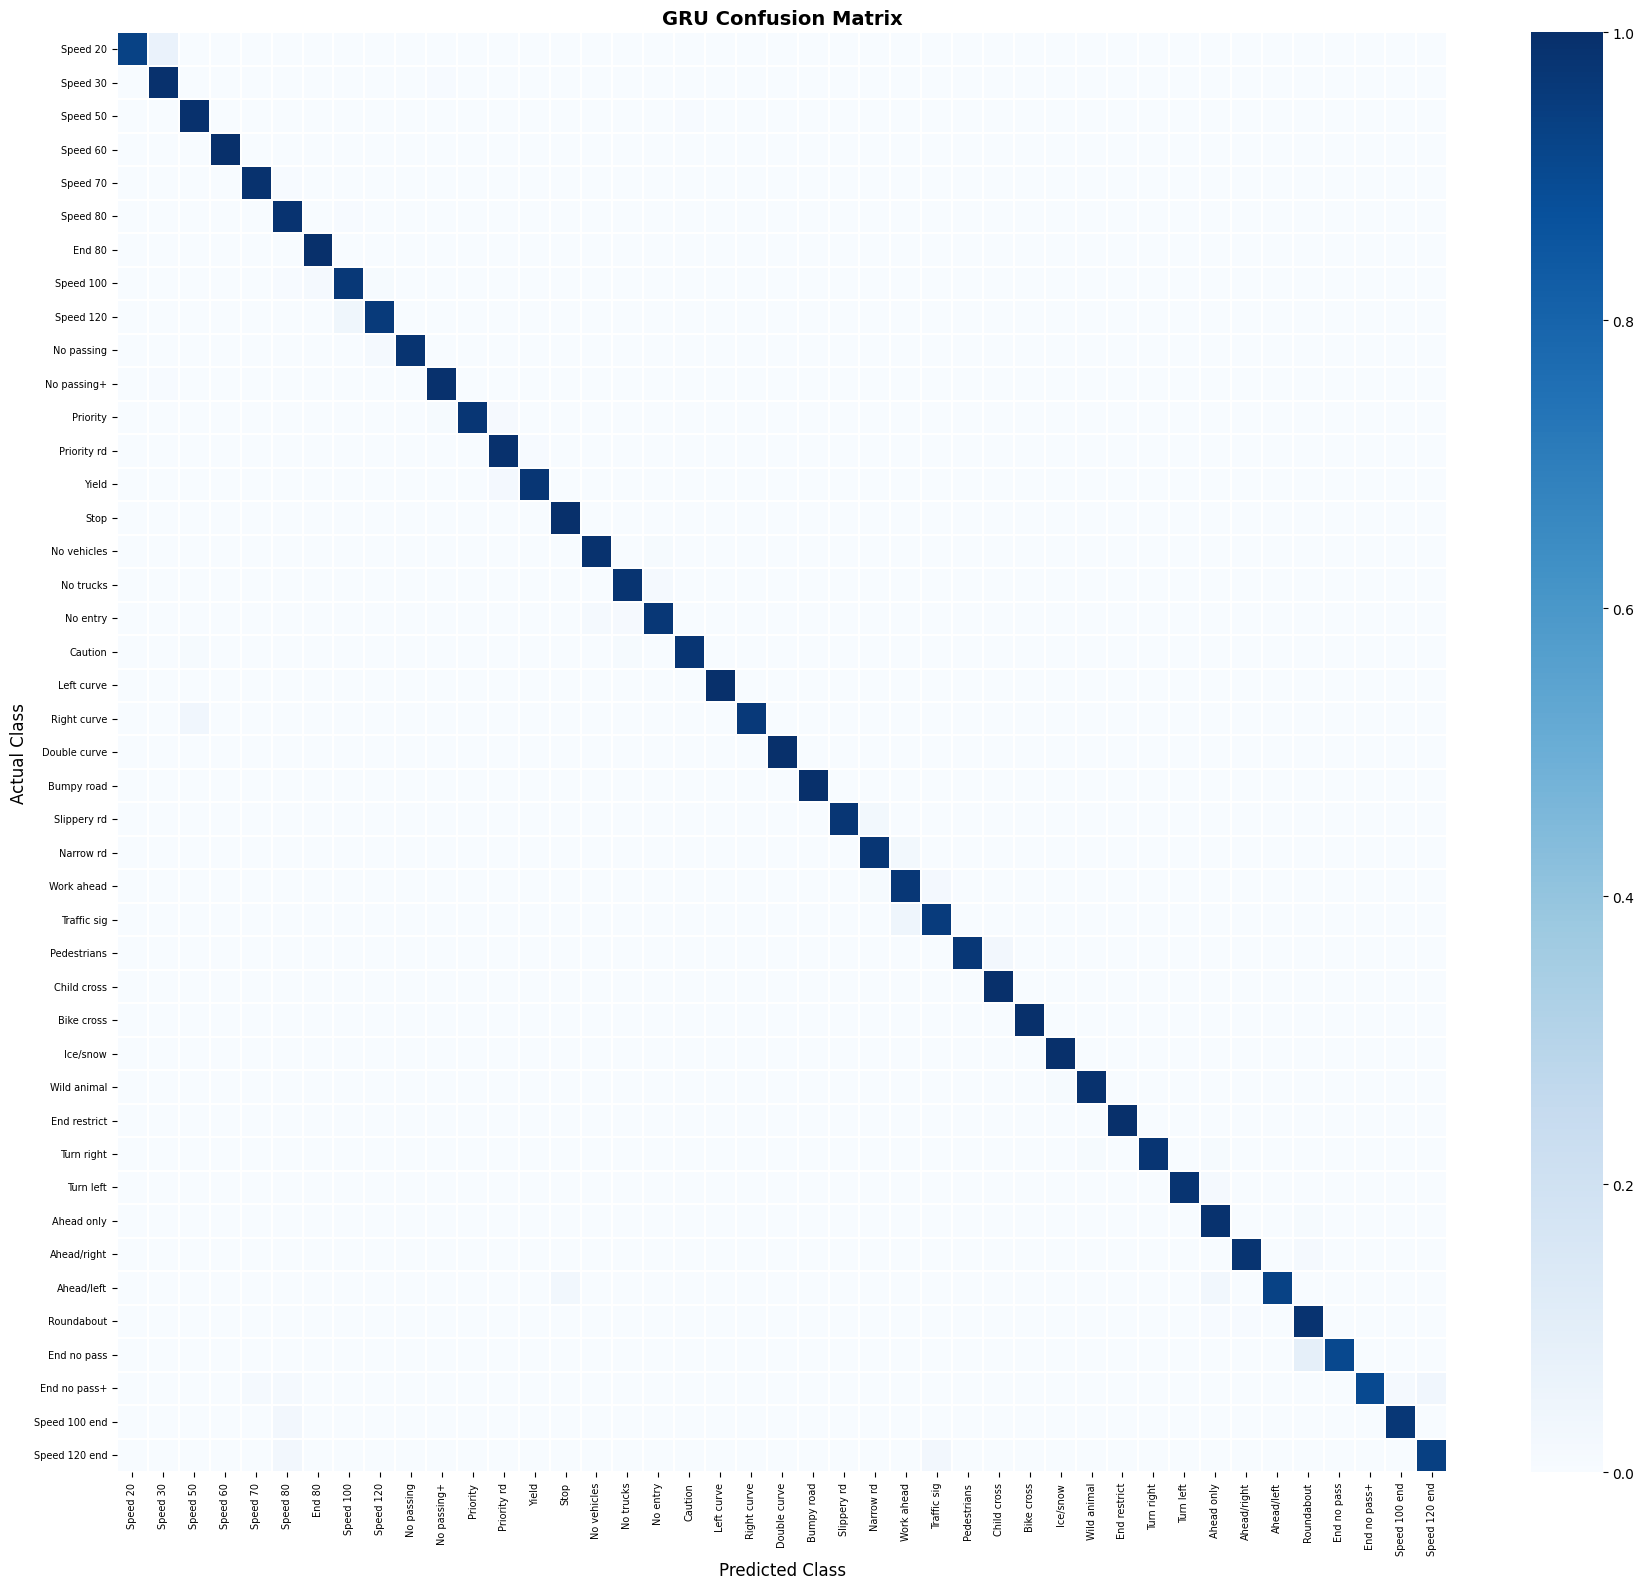

In [21]:
plot_confusion_matrix(metrics,"GRU")

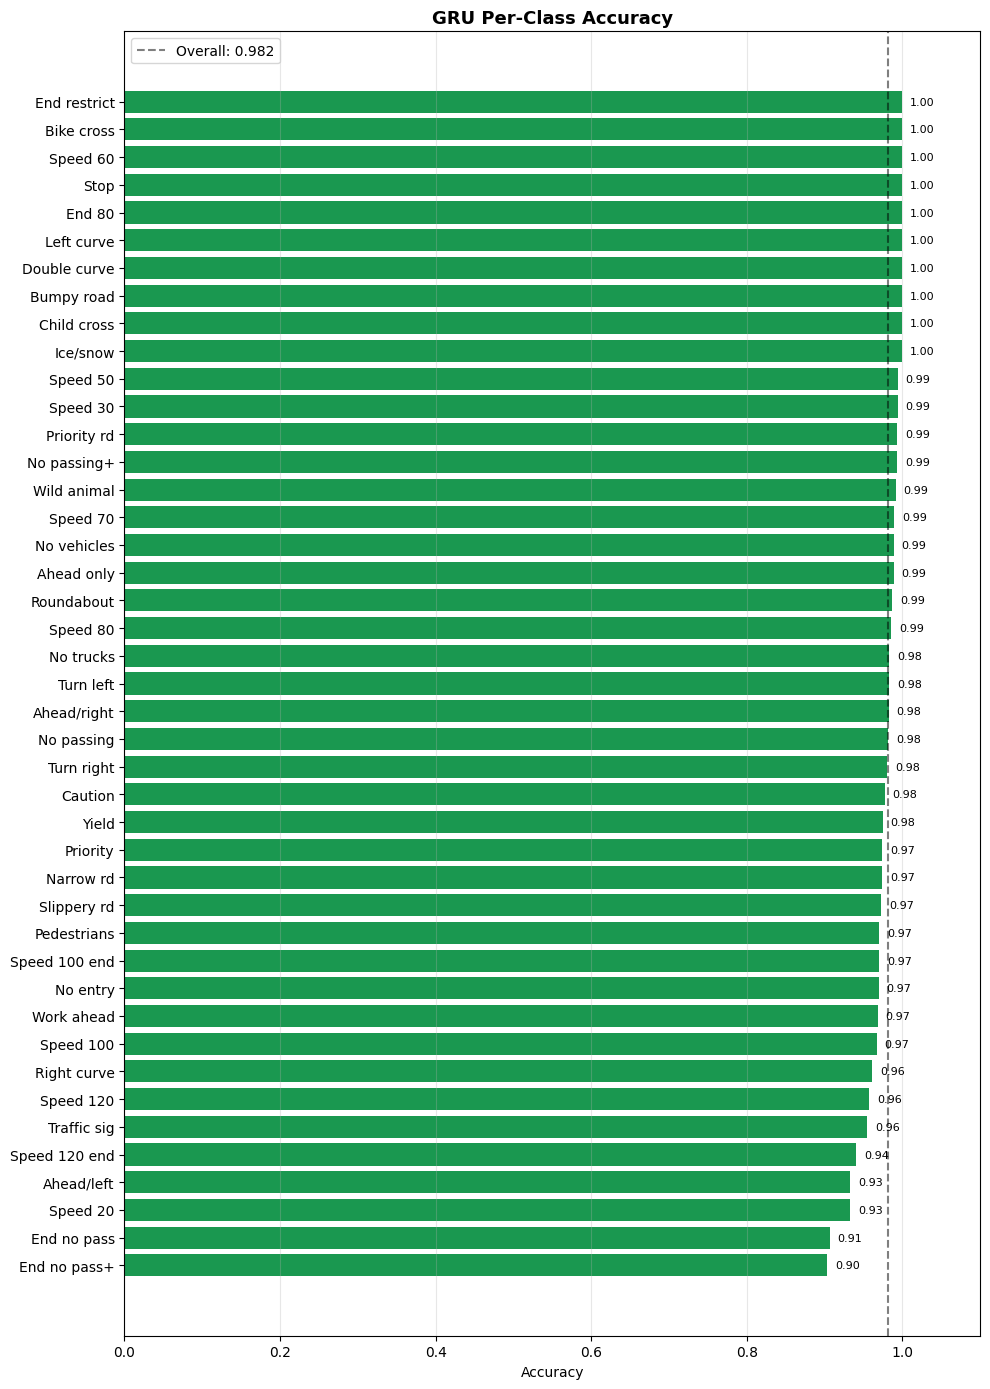

In [22]:
plot_per_class_accuracy(metrics,"GRU")

# LSTM Model

## Training

In [ ]:
from ModelsP import load_data, build_model, train_model, evaluate_model

train_loader, val_loader, test_loader = load_data()
model   = build_model(model_type='lstm')
trainer = train_model(model, train_loader, val_loader)
metrics = evaluate_model(trainer, test_loader)

## Plots

In [ ]:
plot_training_curves(trainer, "LSTM")

In [ ]:
plot_confusion_matrix(metrics, "LSTM")

In [ ]:
plot_per_class_accuracy(metrics, "LSTM")